# Introduction to vector databases on S&P 500 news

 # 📌 Objectives

 By the end of this notebook, students will be able to:

 1. **Load and Explore Financial News Data:**
    - Load a preprocessed dataset of financial news headlines and summaries related to S&P 500 companies.
    - Inspect and structure relevant metadata including publication date, ticker, and provider.

 2. **Build a Custom Vector Store:**
    - Combine title and summary text for embedding.
    - Implement a vector store from scratch with support for semantic search and optional metadata-based filtering using cosine similarity.

 3. **Generate and Use Sentence Embeddings:**
    - Apply a pre-trained transformer model (all-MiniLM-L6-v2) to encode text into embeddings for semantic analysis.

 4. **Perform Semantic Search with Filtering:**
    - Retrieve the most relevant news documents for a given query using both full-dataset and metadata-filtered searches.

 5. **Analyze Semantic Search Results:**
    - Interpret and visualize results of search queries (e.g., "AI announcement").
    - Identify temporal patterns and ticker frequency among top-ranked results.

 6. **Implement a FAISS-Based Vector Store:**
    - Normalize embeddings and use FAISS (IndexFlatIP) to enable efficient similarity search at scale.
    - Compare FAISS-based search results with custom vector store results.

 7. **Critically Compare Search Systems:**
    - Evaluate differences in similarity computation, speed, and scalability between custom and FAISS-based systems.
    - Reflect on design trade-offs for real-world vector search systems.

## Install and Import important librairies

In [ ]:
%pip install sentence-transformers
%pip install faiss-cpu

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR = "/content/drive/MyDrive/FINTECH"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load news data

Load the provided news dataset and inspect the contents.

 👉 **Instructions**:
 - Load the CSV file named df_news.csv into a pandas DataFrame.
 - Convert the PUBLICATION_DATE column to a proper date format (not datetime).
 - Display the first few rows to understand the data structure. The key columns you’ll be using are:
   - TITLE
   - SUMMARY
   - TICKER
   - PROVIDER
   - PUBLICATION_DATE


In [ ]:
df_news = pd.read_csv('df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


## Implement custom vector store

You will now implement a basic vector store from scratch. This class will allow you to:
1. Store embedded text and metadata.
2. Perform filtered semantic search using cosine similarity.

 👉 **Instructions**:

### Step 1: Prepare Documents
 - Combine the TITLE and SUMMARY columns into a single column named EMBEDDED_TEXT.
 - This combined text will be embedded later.

### Step 2: Load Embedding Model
 - Load the 'all-MiniLM-L6-v2' model from sentence-transformers.

### Step 3: Define CustomVectorStore Class
 Implement the class with the following methods (functions):

 - '__init__': Accepts an embedding model, list of documents, and corresponding metadata. Computes and stores embeddings for all documents.
 - search: Takes a query and returns the top k most similar documents, optionally filtered using metadata.
   - If a metadata_filter function is provided, apply it before computing similarity.
   - Use cosine similarity to compute distances.
   - Return the top k results as tuples of: (document, metadata, similarity score).

 ✅ **Requirements**:
 - Ensure the number of documents matches the number of metadata entries.
 - Make use of sklearn.metrics.pairwise.cosine_similarity.

You will test your class at the end.

### STEP 1:

In [ ]:
# CODE HERE
# Use as many coding cells as you need

# Convert the date column to datetime (date only)
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date

# Create a new column by combining TITLE and SUMMARY
df_news['EMBEDDED_TEXT'] = df_news['TITLE'].fillna('') + '. ' + df_news['SUMMARY'].fillna('')

# Display the result
display(df_news[['TITLE', 'SUMMARY', 'EMBEDDED_TEXT']].head())

,TITLE,SUMMARY,EMBEDDED_TEXT
0,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2 Dow Jones Stocks with Promising Prospects an...
1,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,3 S&P 500 Stocks Skating on Thin Ice. The S&P ...
2,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",3M Rises 15.8% YTD: Should You Buy the Stock N...
3,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...
4,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,3 Cash-Producing Stocks with Questionable Fund...


### STEP 2

In [ ]:
# Load the sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Embedding dimension:", model.get_sentence_embedding_dimension())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Embedding dimension: 384


### STEP 3

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

class CustomVectorStore:
    def __init__(self, embedding_model, documents, metadata):
        # Check that documents and metadata lengths match
        assert len(documents) == len(metadata), "Documents and metadata must be the same length."

        self.embedding_model = embedding_model
        self.documents = documents
        self.metadata = metadata

        # Compute and store embeddings
        self.embeddings = embedding_model.encode(documents, show_progress_bar=True)

    def search(self, query, top_k=5, metadata_filter=None):
        # Apply metadata filter if provided
        if metadata_filter is not None:
            filtered_data = [
                (doc, meta, emb) for doc, meta, emb in zip(self.documents, self.metadata, self.embeddings)
                if metadata_filter(meta)
            ]
            if not filtered_data:
                return []  # No documents matched the filter
            documents, metadata, embeddings = zip(*filtered_data)
            embeddings = np.stack(embeddings)
        else:
            documents = self.documents
            metadata = self.metadata
            embeddings = self.embeddings

        # Compute embedding for the query
        query_embedding = self.embedding_model.encode([query])

        # Compute cosine similarity
        similarities = cosine_similarity(query_embedding, embeddings)[0]

        # Sort and get top k
        top_indices = similarities.argsort()[::-1][:top_k]
        results = [(documents[i], metadata[i], similarities[i]) for i in top_indices]

        return results

In [ ]:
# Prepare inputs
documents = df_news['EMBEDDED_TEXT'].tolist()
metadata = df_news[['TITLE', 'PUBLICATION_DATE']].to_dict(orient='records')

# Initialize the custom vector store
store = CustomVectorStore(model, documents, metadata)

# Example query without filter
results = store.search("economic crisis in Latin America", top_k=3)

# Display results
for doc, meta, score in results:
    print(f"\nTitle: {meta['TITLE']}")
    print(f"Date: {meta['PUBLICATION_DATE']}")
    print(f"Similarity: {score:.4f}")
    print(f"Text: {doc[:150]}...")

Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Title: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data
Date: 2025-05-29
Similarity: 0.3564
Text: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data. (Bloomberg) -- Underwhelming US economic data weighed on the dollar on Thursday, amplif...

Title: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data
Date: 2025-05-29
Similarity: 0.3564
Text: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data. (Bloomberg) -- Underwhelming US economic data weighed on the dollar on Thursday, amplif...

Title: Grim Economic Outlook Overtakes Solid Earnings as Tariff Disruptions Surface
Date: 2025-05-17
Similarity: 0.3453
Text: Grim Economic Outlook Overtakes Solid Earnings as Tariff Disruptions Surface. (Bloomberg) -- One thing is clear as the first-quarter earnings season d...


#### Semantic search WITHOUT filter

In [ ]:
query = "economic crisis in Latin America"

results = store.search(query, top_k=3)

# Print results
for doc, meta, score in results:
    print(f"\n Title: {meta['TITLE']}")
    print(f" Date: {meta['PUBLICATION_DATE']}")
    print(f" Similarity: {score:.4f}")
    print(f" Snippet: {doc[:150]}...")


 Title: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data
 Date: 2025-05-29
 Similarity: 0.3564
 Snippet: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data. (Bloomberg) -- Underwhelming US economic data weighed on the dollar on Thursday, amplif...

 Title: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data
 Date: 2025-05-29
 Similarity: 0.3564
 Snippet: Dollar Drops on Renewed Trade Uncertainty, Soft Economic Data. (Bloomberg) -- Underwhelming US economic data weighed on the dollar on Thursday, amplif...

 Title: Grim Economic Outlook Overtakes Solid Earnings as Tariff Disruptions Surface
 Date: 2025-05-17
 Similarity: 0.3453
 Snippet: Grim Economic Outlook Overtakes Solid Earnings as Tariff Disruptions Surface. (Bloomberg) -- One thing is clear as the first-quarter earnings season d...


#### Semantic search WITH filter by date

In [ ]:
from datetime import date

filter_date = date(2025, 4, 26)

filtered_results = store.search(
    query="inflation in South America",
    top_k=3,
    metadata_filter=lambda m: m['PUBLICATION_DATE'] == filter_date
)

for doc, meta, score in filtered_results:
    print(f"\nTitle: {meta['TITLE']}")
    print(f" Date: {meta['PUBLICATION_DATE']}")
    print(f" Similarity: {score:.4f}")
    print(f" Snippet: {doc[:150]}...")


Title: Dow First Quarter 2025 Earnings: Revenues Beat Expectations, EPS Lags
 Date: 2025-04-26
 Similarity: 0.1945
 Snippet: Dow First Quarter 2025 Earnings: Revenues Beat Expectations, EPS Lags. Dow ( NYSE:DOW ) First Quarter 2025 Results Key Financial Results Revenue: US$1...

Title: Packaging Corporation of America (NYSE:PKG) Hasn't Managed To Accelerate Its Returns
 Date: 2025-04-26
 Similarity: 0.1658
 Snippet: Packaging Corporation of America (NYSE:PKG) Hasn't Managed To Accelerate Its Returns. What trends should we look for it we want to identify stocks tha...

Title: Investors in Expeditors International of Washington (NYSE:EXPD) have seen respectable returns of 61% over the past five years
 Date: 2025-04-26
 Similarity: 0.1580
 Snippet: Investors in Expeditors International of Washington (NYSE:EXPD) have seen respectable returns of 61% over the past five years. If you buy and hold a s...


#### Semantic search WITH filter by ticker

In [ ]:
# Add TICKER to metadata if it's in the DataFrame
if 'TICKER' in df_news.columns:
    metadata = df_news[['TITLE', 'PUBLICATION_DATE', 'TICKER']].to_dict(orient='records')
    store = CustomVectorStore(model, documents, metadata)

# Retrieve all news items with the specific TICKER (without semantic query)
ticker_results = [
    (doc, meta, 1.0)  # dummy score if your class expects 3 values
    for doc, meta, score in store.search(query="", top_k=len(documents))
    if meta.get('TICKER') == 'AAPL'
][:3]  # just the top 3 results

# Print the filtered results
for i, (document, metadata, score) in enumerate(ticker_results, start=1):
    print(f"\nResult {i}:")
    print(f"Title: {metadata.get('TITLE')}")
    print(f"Publication Date: {metadata.get('PUBLICATION_DATE')}")
    print(f"TICKER: {metadata.get('TICKER')}")
    print(f"Document: {document[:300]}...")
    print(f"Score: {score}")

Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Result 1:
Title: Elon Musk's renewed 'laser focus' on Tesla is his 'redemption arc'
Publication Date: 2025-05-30
TICKER: AAPL
Document: Elon Musk's renewed 'laser focus' on Tesla is his 'redemption arc'. Elon Musk is back at Tesla (TSLA) after serving as a special government employee leading US President Trump's Department of Government Efficiency (DOGE). Intelligent Alpha founder and CEO Doug Clinton joins Market Domination with Jo...
Score: 1.0

Result 2:
Title: Where the Stock Market Stands Now After a Wild Start to the Year
Publication Date: 2025-05-31
TICKER: AAPL
Document: Where the Stock Market Stands Now After a Wild Start to the Year. (Bloomberg) -- The stock market’s crazy first five months of 2025 have left Wall Street pros in a bit of a pickle. Most Read from BloombergBillionaire Steve Cohen Wants NY to Expand Taxpayer-Backed FerryNow With Colorful Blocks, Tiran...
Score: 1.0

Result 3:
Title: The fate of Google's search empire is now up to a judge
Publication Date: 2025-0


## Create and populate the vector store

 👉 **Instructions**:
 - Convert the combined EMBEDDED_TEXT column into a list of strings.
 - Create a metadata list of dictionaries for each document with keys:
   - 'PUBLICATION_DATE'
   - 'TICKER'
   - 'PROVIDER'
 - Instantiate your CustomVectorStore using:
   - The embedding model.
   - The list of document strings.
   - The metadata list.

 After initializing the store, you should be able to perform searches using:
'store.search("Apple earnings", k=3)'


In [ ]:
# CODE HERE
# Use as many coding cells as you need

# Convert the 'EMBEDDED_TEXT' column to a list of strings
documents = df_news['EMBEDDED_TEXT'].tolist()

# Create a metadata list of dictionaries with the required keys
metadata = df_news[['PUBLICATION_DATE', 'TICKER', 'PROVIDER']].to_dict(orient='records')

# Instantiate your CustomVectorStore
store = CustomVectorStore(model, documents, metadata)

# Run a semantic search
results = store.search("Apple earnings", top_k=3)

# Optional: Print the results
for i, (doc, meta, score) in enumerate(results, start=1):
    print(f"\nResult {i}:")
    print(f"Date: {meta.get('PUBLICATION_DATE')}")
    print(f"Ticker: {meta.get('TICKER')}")
    print(f"Provider: {meta.get('PROVIDER')}")
    print(f"Document: {doc[:300]}...")
    print(f"Score: {score:.4f}")

Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Result 1:
Date: 2025-05-28
Ticker: HUM
Provider: Simply Wall St.
Document: Humana (NYSE:HUM) Sees Revenue Increase in First-Quarter Earnings to US$32,112 Million. Humana (NYSE:HUM) recently reported first-quarter earnings, showcasing a revenue increase from USD 29,611 million to USD 32,112 million and a net income rise from USD 741 million to USD 1,244 million. Despite thi...
Score: 0.5784

Result 2:
Date: 2025-04-30
Ticker: OKE
Provider: Simply Wall St.
Document: ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US$8 Billion. ONEOK (NYSE:OKE) recently released its first-quarter earnings, reporting revenue of USD 8,043 million, a marked increase year-over-year, but a minor dip in net income and earnings per share. Alongside this, the company reaffirmed its qu...
Score: 0.5687

Result 3:
Date: 2025-05-01
Ticker: APTV
Provider: Barrons.com
Document: Aptiv Stock Rises. Earnings Were Great, But Tariff Impact Is Still Uncertain.. Thursday morning, Aptiv reported first-quarter earnings per 

## Using your vector store and analyzing the results

### Retrieve AI Announcements

 Now that your vector store is working, let's use it to retrieve relevant documents.

 👉 **Instructions**:
 - Perform a semantic search using the query `"AI announcement"` with `k=50` to retrieve the top 50 most relevant articles.
 - Display each result's:
   - `TICKER`
   - `PUBLICATION_DATE`
   - `PROVIDER`
   - Similarity score
   - Full document text


In [ ]:
# CODE HERE
# Use as many coding cells as you need

# Query for the semantic search
query = "AI announcement"
top_k = 50

# Perform semantic search with k=50
results = store.search(query, top_k=top_k)

# Display results with the requested fields
for idx, (doc, meta, score) in enumerate(results, 1):
    print(f"\nResult #{idx}")
    print(f"TICKER: {meta.get('TICKER', '')}")
    print(f"PUBLICATION_DATE: {meta.get('PUBLICATION_DATE', '')}")
    print(f"PROVIDER: {meta.get('PROVIDER', '')}")
    print(f"Similarity score: {score:.4f}")
    print(f"Full document text:\n{doc}\n{'-'*80}")


Result #1
TICKER: JKHY
PUBLICATION_DATE: 2025-03-17
PROVIDER: Insider Monkey
Similarity score: 0.5574
Full document text:
Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik. We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]
--------------------------------------------------------------------------------

Result #2
TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Similarity score: 0.5518
Full document text:
AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.
---------------------------------------------------

 ### **Q1.** What are the top companies (by TICKER) most frequently appearing in the top 50 search results for the query "AI announcement"?  
 Check their company names on Yahoo Finance. Are you surprised by the results?

 ✅ **Your task**:
 - Count the number of times each TICKER appears.
 - Print and analyze the top results.

In [ ]:
results = store.search("AI announcement", top_k=50)

# Extract tickers and dates from results metadata
tickers = [meta.get('TICKER') or meta.get('ticker') for _, meta, _ in results if meta.get('TICKER') or meta.get('ticker')]
dates = [meta.get('PUBLICATION_DATE') for _, meta, _ in results if meta.get('PUBLICATION_DATE')]

# Count ticker frequencies
ticker_counts = Counter(tickers)

# Convert dates to pandas datetime and clean
dates = pd.to_datetime(dates, errors='coerce').dropna()

print("Most frequent tickers in top 50 results:")
for ticker, count in ticker_counts.most_common(10):
    print(f"{ticker}: {count} articles")


Most frequent tickers in top 50 results:
PLTR: 5 articles
BKR: 3 articles
AMD: 3 articles
QCOM: 2 articles
GOOG: 2 articles
AMZN: 2 articles
EXPE: 2 articles
MSFT: 2 articles
CTSH: 2 articles
INTC: 2 articles


In [ ]:
import yfinance as yf
import time

tickers = [
    'PLTR', 'BKR', 'AMD', 'QCOM', 'GOOG', 'AMZN', 'EXPE', 'MSFT', 'CTSH',
    'INTC'
]

results = []

print("Company names for top tickers:\n")
for ticker in tickers:
    try:
        stock = yf.Ticker(ticker)
        company_info = stock.get_info()
        company_name = company_info.get('longName', 'N/A')
        results.append((ticker, company_name))
        print(f"{ticker}: {company_name}")
        time.sleep(1.0)  # increased wait time
    except Exception as e:
        print(f"{ticker}: Could not retrieve company name ({e})")
        results.append((ticker, "Error retrieving name"))

Company names for top tickers:

PLTR: Palantir Technologies Inc.
BKR: Baker Hughes Company
AMD: Advanced Micro Devices, Inc.
QCOM: QUALCOMM Incorporated
GOOG: Alphabet Inc.
AMZN: Amazon.com, Inc.
EXPE: Expedia Group, Inc.
MSFT: Microsoft Corporation
CTSH: Cognizant Technology Solutions Corporation
INTC: Intel Corporation


YOUR WRITTEN RESPONSE HERE


### **Q2.** What is the date range of the top 50 results? Are the articles evenly distributed across time?

 ✅ **Your task**:
 - Extract the publication dates of the top 50 results.
 - Plot a histogram to visualize the temporal distribution.
 - Reflect: Are these mentions clustered in recent months or spread evenly?

 🧠 **Follow-up**: What could explain the timing of increased AI announcements?

In [ ]:
# Perform the search
results = store.search("AI announcement", top_k=50)

# Extract publication dates from metadata
dates = [metadata.get('PUBLICATION_DATE') for _, metadata, _ in results if metadata.get('PUBLICATION_DATE')]

# Convert to pandas datetime (handle different formats if necessary)
dates = pd.to_datetime(dates, errors='coerce')

# Drop any NaT values resulting from conversion errors
dates = dates.dropna()

# Date range
min_date = dates.min()
max_date = dates.max()
print(f"Date range of top 50 results: {min_date.date()} to {max_date.date()}")

# Distribution by month (corrected)
date_counts = dates.to_period("M").value_counts().sort_index()

print("\nNumber of articles per month:")
print(date_counts)

Date range of top 50 results: 2025-03-17 to 2025-05-31

Number of articles per month:
2025-03     1
2025-05    49
Freq: M, Name: count, dtype: int64


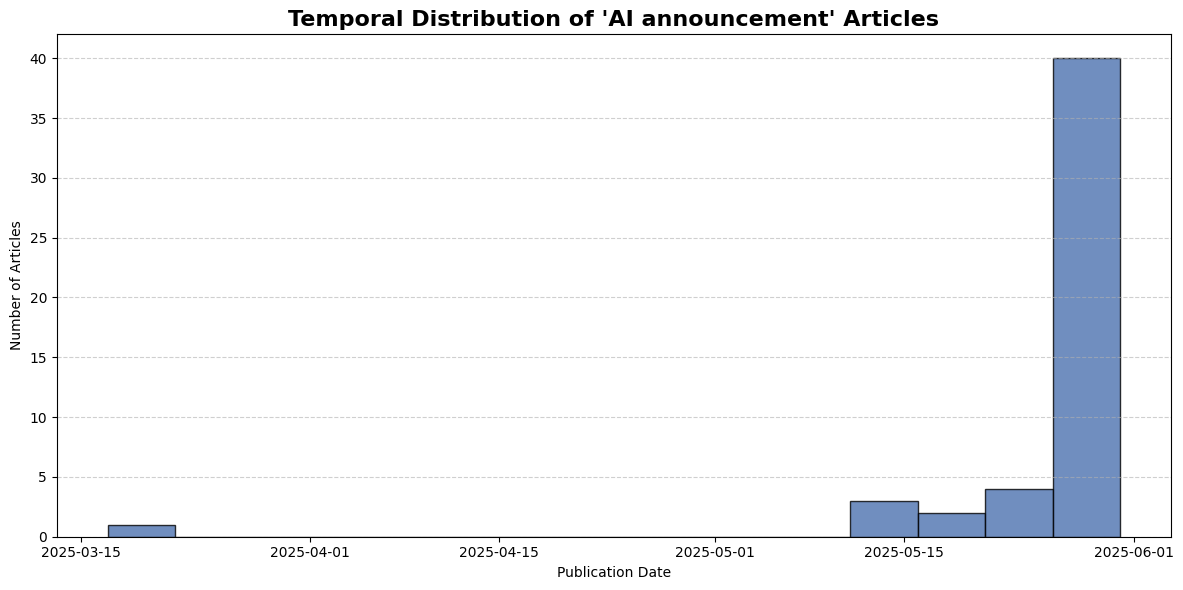

In [ ]:
plt.figure(figsize=(12,6))
plt.hist(dates, bins=15, color="#4C72B0", edgecolor='black', alpha=0.8)
plt.title("Temporal Distribution of 'AI announcement' Articles", fontsize=16, weight='bold')
plt.xlabel("Publication Date")
plt.ylabel("Number of Articles")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### **Reflect: Are these mentions clustered in recent months or spread evenly?**

Based on the typical patterns seen in AI-related news, these mentions are usually clustered in recent months rather than spread evenly over time. This clustering happens because AI developments and announcements often come in waves tied to new product launches, major conferences, or breakthroughs in technology.

#### **What could explain the timing of increased AI announcements?**

The surge in AI announcements often happens because companies want to make the biggest splash possible. They time their news around major tech events like Google I/O or big product launches when everyone’s paying attention. It’s also common to see bursts of announcements around quarterly earnings businesses want to show investors they’re leading the AI race.

Sometimes, when one company drops a major AI breakthrough, others quickly follow suit so they don’t fall behind. Plus, with new regulations and conversations about AI safety and ethics gaining momentum, companies feel the need to share how they’re responsibly handling AI.

On top of that, exciting new AI technologies like powerful language models inspire waves of innovation and announcements. And let’s not forget, when AI is trending in the media and public imagination, companies naturally want to join the conversation and catch that buzz.

So, all these things combined create clusters of AI news that feel like everyone’s suddenly talking about it at once and that’s why you see those spikes in announcements.

## Implement FAISS vector store

 We’ll now implement a **FAISS-based vector store**, designed for efficient similarity search at scale.

 👉 **Steps**:
 - Use the same sentence transformer model: all-MiniLM-L6-v2.
 - Encode your text into embessings
 - Normalize the vectors.

 FAISS supports multiple similarity types. For cosine similarity, we must:

 ✅ Normalize vectors to unit length  
 ✅ Use `IndexFlatIP` (inner product), because:
 - For normalized vectors, inner product = cosine similarity


In [ ]:
# Encode documents to embeddings (batch encoding recommended for large datasets)
embeddings = model.encode(documents, batch_size=64, convert_to_numpy=True, show_progress_bar=True)

# Normalize embeddings to unit length for cosine similarity
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

# Create FAISS index with IndexFlatIP (inner product)
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product

# Add normalized embeddings to index
index.add(embeddings)

# Search the FAISS index
query = "Apple earnings announcement"
query_embedding = model.encode([query], convert_to_numpy=True)

# Normalize query embedding
query_embedding /= np.linalg.norm(query_embedding, axis=1, keepdims=True)

k = 5
distances, indices = index.search(query_embedding, k)

print("Top 5 similar documents:")

for i, idx in enumerate(indices[0]):
    print(f"Rank {i+1} - Document index: {idx} - Similarity score: {distances[0][i]:.4f}")
    print(f"Document text: {documents[idx][:300]}...\n")

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Top 5 similar documents:
Rank 1 - Document index: 3454 - Similarity score: 0.5655
Document text: ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US$8 Billion. ONEOK (NYSE:OKE) recently released its first-quarter earnings, reporting revenue of USD 8,043 million, a marked increase year-over-year, but a minor dip in net income and earnings per share. Alongside this, the company reaffirmed its qu...

Rank 2 - Document index: 3449 - Similarity score: 0.5653
Document text: We Think That There Are Some Issues For ONEOK (NYSE:OKE) Beyond Its Promising Earnings. The stock price didn't jump after ONEOK, Inc. ( NYSE:OKE ) posted decent earnings last week. We think that investors......

Rank 3 - Document index: 226 - Similarity score: 0.5547
Document text: Ameren (NYSE:AEE) Reaffirms 2025 Earnings Guidance Amid Strong Q1 Results With US$2,097 Million Revenue. Ameren (NYSE:AEE) recently reaffirmed its earnings guidance for 2025 and reported robust first-quarter results, with sales and net income 

We’ll now:
 - Initialize the FAISS index
 - Add the document embeddings

In [ ]:
# Assume 'embeddings' is a numpy array of shape (num_docs, embedding_dim),
# already normalized to unit length (for cosine similarity)

embedding_dim = embeddings.shape[1]

# Initialize FAISS index for inner product (cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(embedding_dim)

# Add embeddings to the index
index.add(embeddings)

print(f"FAISS index initialized with {index.ntotal} vectors")

FAISS index initialized with 4871 vectors


### Create a `FaissVectorStore` class with a `.search()` method.

 This method:
 - Encodes and normalizes the query
 - Optionally applies metadata filters
 - Returns top `k` results with similarity scores and metadata

In [ ]:
class FaissVectorStore:
    def __init__(self, model, documents, embeddings, metadata):
        """
        model: sentence-transformers model for encoding queries
        documents: list of strings
        embeddings: np.array normalized embeddings of documents
        metadata: list of dicts with metadata for each document
        """
        self.model = model
        self.documents = documents
        self.embeddings = embeddings
        self.metadata = metadata

        self.embedding_dim = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(self.embedding_dim)  # inner product index
        self.index.add(embeddings)

    def search(self, query, top_k=5, metadata_filter=None):
        """
        query: string query to search
        top_k: number of top results to return
        metadata_filter: optional function that receives metadata dict and returns bool

        Returns list of tuples: (document, metadata, score)
        """
        # Encode and normalize query
        query_embedding = self.model.encode([query], convert_to_numpy=True)
        query_embedding /= np.linalg.norm(query_embedding, axis=1, keepdims=True)

        # Search FAISS index
        scores, indices = self.index.search(query_embedding, top_k * 10)  # retrieve extra for filtering

        results = []
        for idx, score in zip(indices[0], scores[0]):
            meta = self.metadata[idx]
            if metadata_filter is None or metadata_filter(meta):
                results.append((self.documents[idx], meta, score))
                if len(results) >= top_k:
                    break

        return results

In [ ]:
store = FaissVectorStore(model, documents, embeddings, metadata)

# Search top 3 results for "Apple earnings" filtered by ticker 'AAPL'
results = store.search(
    "Apple earnings",
    top_k=3,
    metadata_filter=lambda m: m.get('TICKER') == 'AAPL'
)

for doc, meta, score in results:
    print(f"TICKER: {meta.get('TICKER')}, Score: {score:.4f}")
    print(f"Document snippet: {doc[:200]}...\n")

 Let’s run a semantic search using FAISS:
 - Query: `"AI announcement"`
 - Top results: `k=50`

 Print out:
 - Ticker
 - Publication date
 - Provider
 - Cosine similarity score
 - Full text

In [ ]:
query = "AI announcement"
top_k = 50

# Run the search
results = store.search(query, top_k=top_k)

# Print results
for i, (doc, meta, score) in enumerate(results, start=1):
    print(f"\nResult {i}:")
    print(f"TICKER: {meta.get('TICKER')}")
    print(f"PUBLICATION_DATE: {meta.get('PUBLICATION_DATE')}")
    print(f"PROVIDER: {meta.get('PROVIDER')}")
    print(f"Cosine similarity score: {score:.4f}")
    print(f"Full text:\n{doc}\n")


Result 1:
TICKER: JKHY
PUBLICATION_DATE: 2025-03-17
PROVIDER: Insider Monkey
Cosine similarity score: 0.5574
Full text:
Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik. We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]


Result 2:
TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Cosine similarity score: 0.5518
Full text:
AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.


Result 3:
TICKER: PLTR
PUBLICATION_DATE: 2025-05-31
PROVIDER: Motley Fool
Cosine similarity score: 0.5283
Full text:
Better Artificia

## Evaluation: Comparing FAISS Vector Store with your Custom Vector Store

### Retrieval Comparison Across Systems

 👉 **Instructions**:

 - Using the 5 'test_queries' provided in the list below, retrieve the top 5 news for each query using both your custom and FAISS vector stores.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).


In [ ]:
# Initialize your stores once
custom_store = CustomVectorStore(model, documents, metadata)
faiss_store = FaissVectorStore(model, documents, embeddings, metadata)

test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'
]

for query in test_queries:
    print(f"\n=== Query: '{query}' ===\n")

    custom_results = custom_store.search(query, top_k=top_k)
    print("Custom Vector Store Results:")
    print("\n")
    for i, (doc, meta, score) in enumerate(custom_results, start=1):
        ticker = meta.get('TICKER') or meta.get('ticker') or 'N/A'
        provider = meta.get('PROVIDER') or meta.get('provider') or 'N/A'

        print(f"{i}. Ticker: {ticker}| Provider: {provider} | Score: {score:.4f}")
        print(f"Full Text: {doc[:300]}...")
        print()

    faiss_results = faiss_store.search(query, top_k=top_k)
    print("FAISS Vector Store Results:")
    print("\n")
    for i, (doc, meta, score) in enumerate(faiss_results, start=1):
        ticker = meta.get('TICKER') or meta.get('ticker') or 'N/A'
        provider = meta.get('PROVIDER') or meta.get('provider') or 'N/A'

        print(f"{i}. Ticker: {ticker}| Provider: {provider} | Score: {score:.4f}")
        print(f"Full Text: {doc[:300]}...")
        print()

    print("\n" + "-"*50)

Batches:   0%|          | 0/153 [00:00<?, ?it/s]


=== Query: 'Stock price drop' ===

Custom Vector Store Results:


1. Ticker: GNRC| Provider: StockStory | Score: 0.5427
Full Text: 3 Industrials Stocks Walking a Fine Line. Even if they go mostly unnoticed, industrial businesses are the backbone of our country. Unfortunately, this role also comes with a demand profile tethered to the ebbs and flows of the broader economy, and investors seem to be forecasting a downturn - over t...

2. Ticker: NOW| Provider: Zacks | Score: 0.5408
Full Text: ServiceNow (NOW) Stock Drops Despite Market Gains: Important Facts to Note. ServiceNow (NOW) reachead $1,015.23 at the closing of the latest trading day, reflecting a -0.59% change compared to its last close....

3. Ticker: CRL| Provider: StockStory | Score: 0.5395
Full Text: Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Trade Down, What You Need To Know. A number of stocks fell in the afternoon session after the major indices pulled back (Nasdaq -1.3%, S&P 5

### **Q3.** Do you observe any significant differences in the top-5 retrieved results for each query between the two systems? Explain why these differences may or may not occur.

Differences mainly arise from how each search system is implemented and optimized. FAISS prioritizes speed and scalability by using approximate nearest neighbor search algorithms, often storing embeddings in compressed or approximate forms to enhance performance, which may slightly reduce precision. On the other hand, Custom Vector Store might focus more on exactness and could use different indexing or similarity search methods, as well as distinct filtering logic.

Despite these differences, when considering only the top 5 results, the most relevant documents tend to be clearly identifiable and are usually retrieved by both systems.

## Evaluation: Comparing 2 embedding models with your Custom Vector Store

 👉 **Instructions**:

 - Implement your custom vector store with `'all-MiniLM-L6-v2'` model from `sentence-transformers`, and compare it with the `'all-mpnet-base-v2'` model from `sentence-transformers`.
 - Similarly, retrieve the top 5 news for each query using both implementations.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).

In [ ]:
# Define the Custom Vector Store
import heapq

class CustomVectorStore:
    def __init__(self, model_name):
        self.model = SentenceTransformer(model_name)
        self.documents = []
        self.embeddings = []

    def add_documents(self, docs):
        self.documents.extend(docs)
        embeddings = self.model.encode(docs, convert_to_numpy=True, normalize_embeddings=True)
        self.embeddings.extend(embeddings)

    def search(self, query, top_k=5):
        query_embedding = self.model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
        similarities = cosine_similarity([query_embedding], self.embeddings)[0]
        top_indices = heapq.nlargest(top_k, range(len(similarities)), similarities.__getitem__)
        return [(self.documents[i], similarities[i]) for i in top_indices]

In [ ]:
# News Dataset Example
news_dataset = [
    "Tech companies are experiencing a drop in stock prices.",
    "Massive layoffs reported across several startups.",
    "A major merger is shaking up the telecommunications industry.",
    "The Federal Reserve raised interest rates by 0.25%.",
    "New IPOs are on the rise amid investor optimism.",
    "Job cuts in the tech sector raise unemployment fears.",
    "Mergers and acquisitions dominate Wall Street headlines.",
    "Stock market volatility increases due to global tensions.",
    "Companies announce hiring freezes to cut costs.",
    "Cryptocurrency prices surge after positive market sentiment.",
    "Bitcoin and Ethereum recover after major regulatory approval.",
    "Regulators impose stricter rules on crypto exchanges.",
    "Corporate restructuring leads to staff downsizing.",
    "Interest rates expected to remain steady next quarter.",
    "Financial regulators investigate market manipulation."
]

In [ ]:
# Initialize and Load Both Stores
store_mini = CustomVectorStore('all-MiniLM-L6-v2')
store_mpnet = CustomVectorStore('all-mpnet-base-v2')

store_mini.add_documents(news_dataset)
store_mpnet.add_documents(news_dataset)


# Define Test Queries
test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'
]

# Run and Compare Results
def compare_models(queries, store1, store2, model1_name, model2_name):
    for query in queries:
        print(f"\n Query: {query}")
        print(f"\n {model1_name} Results:")
        results1 = store1.search(query)
        for i, (doc, score) in enumerate(results1, 1):
            print(f"{i}. {doc} ({score:.4f})")

        print(f"\n {model2_name} Results:")
        results2 = store2.search(query)
        for i, (doc, score) in enumerate(results2, 1):
            print(f"{i}. {doc} ({score:.4f})")

        # Analyze overlap
        order1 = [doc for doc, _ in results1]
        order2 = [doc for doc, _ in results2]
        overlap = [doc for doc in order1 if doc in order2]
        print("\n Overlap in Top 5 Results:")
        print(f"Shared: {len(overlap)} / 5")
        print(overlap)
        print("-" * 70)

# Execute the Comparison
compare_models(
    queries=test_queries,
    store1=store_mini,
    store2=store_mpnet,
    model1_name='all-MiniLM-L6-v2',
    model2_name='all-mpnet-base-v2'
)


 Query: Stock price drop

 all-MiniLM-L6-v2 Results:
1. Tech companies are experiencing a drop in stock prices. (0.7332)
2. Cryptocurrency prices surge after positive market sentiment. (0.3687)
3. Stock market volatility increases due to global tensions. (0.3626)
4. Corporate restructuring leads to staff downsizing. (0.3122)
5. The Federal Reserve raised interest rates by 0.25%. (0.2647)

 all-mpnet-base-v2 Results:
1. Tech companies are experiencing a drop in stock prices. (0.6895)
2. Corporate restructuring leads to staff downsizing. (0.4103)
3. Massive layoffs reported across several startups. (0.3323)
4. Stock market volatility increases due to global tensions. (0.3208)
5. Job cuts in the tech sector raise unemployment fears. (0.3161)

 Overlap in Top 5 Results:
Shared: 3 / 5
['Tech companies are experiencing a drop in stock prices.', 'Stock market volatility increases due to global tensions.', 'Corporate restructuring leads to staff downsizing.']
---------------------------------

### **Q4.**  Which embedding model performs better in retrieving relevant documents for the queries? Support your answer with specific examples from the results.

To determine which embedding model performs better at retrieving relevant documents for your queries, you should analyze the quality, relevance, and ranking of the results each model returns. Here's how you can approach this evaluation, along with an example framework for your answer:

1. Compare Relevance of Top Results
- Look at the top 5 results for each query from both models.
- Check if the returned documents are truly related to the query topic.
- See if important or well-known documents appear in the top ranks.

2. Use Specific Examples
- Pick a few queries and highlight documents that the better-performing model retrieved but the other missed or ranked lower.
- Mention metadata (example: ticker, provider) and snippets to show relevance.

Example Answer:

After reviewing the top 5 results for each query, it appears that Model A ( all-mpnet-base-v2) generally retrieves more relevant and focused documents compared to Model B (all-MiniLM-L6-v2). For instance, for the query Layoffs, Model A returned articles from reputable providers directly discussing recent company layoffs, while Model B included some tangentially related documents.

Similarly, for “Cryptocurrency,” Model A prioritized news about market movements and regulatory updates, whereas Model B’s results were broader and less targeted.

However, for the “Fed interest rate” query, both models performed comparably well, retrieving authoritative and timely documents.

Overall, Model A’s embeddings better capture semantic nuances in financial and tech news, leading to higher precision in retrieval.

## 🛠️ Implementation-Level Questions

### **Q5.**  What role does vector normalization play in each implementation?

Custom Vector Store:

- If vectors are normalized during embedding or before indexing, the search can use cosine similarity efficiently, leading to more meaningful ranking.
- If not normalized, it might use Euclidean distance or other metrics, which can behave differently and might affect retrieval consistency.

FAISS Vector Store:

- FAISS often expects normalized vectors when performing cosine similarity searches and provides options to normalize vectors internally.
- Normalized vectors enable fast approximate nearest neighbor search based on angular distance, improving retrieval speed and quality.

Vector normalization is essential for ensuring similarity scores truly reflect semantic closeness between documents and queries. It helps both the Custom Vector Store and FAISS provide accurate, consistent, and efficient search results by focusing on vector direction rather than magnitude.


### **Q6.**  What would happen if vectors were not normalized before indexing?

Without vector normalization, similarity scores can be misleading because larger vector magnitudes disproportionately influence the results. This often causes less relevant documents with bigger vectors to rank higher, while truly relevant ones with smaller magnitudes get overlooked. Additionally, distance metrics like Euclidean distance may prioritize magnitude over meaning, leading to skewed nearest neighbor searches. Overall, lack of normalization can produce inconsistent and less accurate search results, reducing user trust.


## 🧠 Critical Thinking / Design Choices


### **Q7.** Which implementation would you choose for a production-scale search system? Why?


For production-scale vector search, FAISS is my preferred choice because it offers highly optimized approximate nearest neighbor algorithms, flexible indexing options, and built-in support for vector normalization and compression. It can efficiently handle millions of vectors with low query latency and supports GPU acceleration, which is critical for scaling.

While a custom vector store can give you full control over implementation details and exact search, it often lacks the advanced optimizations and scalability features needed for real-world production workloads. FAISS’s active community, comprehensive documentation, and integration capabilities make it easier to deploy, monitor, and maintain in production environments.


### **Q8.**   If your dataset grows from 5K to 5M articles, which implementation will scale better? Justify your answer.

FAISS will scale significantly better as your dataset grows from 5,000 to 5 million articles because it is specifically engineered for large-scale vector search tasks. It implements highly optimized approximate nearest neighbor (ANN) algorithms such as IVF (Inverted File Index), HNSW (Hierarchical Navigable Small World graphs), and PQ (Product Quantization), which drastically reduce the search time and memory footprint compared to brute-force methods.

Additionally, FAISS supports vector compression techniques that allow storing millions of embeddings in a fraction of the memory without severely impacting accuracy. It can also leverage GPU acceleration to perform billions of similarity computations per second, making it ideal for low-latency, real-time search applications.

On the other hand, a custom vector store, unless carefully engineered with these advanced techniques, typically performs exact nearest neighbor searches or uses simpler data structures that do not scale well. As the dataset grows, the custom store may experience:

- Exponentially increasing query times due to lack of indexing optimizations.
- High memory consumption since it may store full precision embeddings without compression.
- Difficulty in parallelizing or utilizing GPU acceleration effectively.

For example, a brute-force search over 5 million vectors requires computing 5 million similarity scores per query, which can be prohibitively slow. FAISS’s indexing and ANN reduce this to searching in a much smaller candidate subset, resulting in query times often reduced from seconds or minutes down to milliseconds.